In [1]:
import os
import numpy as np
from tqdm import tqdm 
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.integrate import solve_ivp

mpl.rc('figure', figsize=(12, 6))
mpl.rc('text', usetex = False)
mpl.rc('font', family = 'serif')
mpl.rc('font', size = '14')
mpl.rc('xtick', labelsize=14) 
mpl.rc('ytick', labelsize=14)
mpl.rcParams['mathtext.fontset'] = 'stix'

In [2]:
"""Definimos las direcciones de los archivos"""

dirN64 = './data/q5050/N64-kIR0.2-kcutoff100/'
dirN128 = './data/q5050/N128-kIR0.2-kcutoff100/'
dirN256 = './data/q5050/N256-kIR0.2-kcutoff100/'

""""Definimos los Ns a graficar"""

N64 = 64
N128 = 128
N256 = 256

# Buscamos las bandas de resonancia

In [3]:
# Función para armarse la matriz de monodromía y calcular los coeficientes de Floquet
def mu_lphi4(k, q, y0, Tosc):
    phi0, phi_dot0 = y0

    def pert(t, y, k, q):
        phi, phi_dot, chi_k, chi_dot_k = y
        phi_ddot = - phi**3
        chi_ddot_k = - (k**2 + q * phi**2) * chi_k
        return [phi_dot, phi_ddot, chi_dot_k, chi_ddot_k]

    t_span = (0, Tosc)

    sol1 = solve_ivp(pert, t_span, [phi0, phi_dot0, 1.0, 0.0], t_eval=[Tosc], method='RK45', rtol=1e-4, args=(k, q))
    y_final1 = sol1.y[:, -1]

    sol2 = solve_ivp(pert, t_span, [phi0, phi_dot0, 0.0, 1.0], t_eval=[Tosc], method='RK45', rtol=1e-4, args=(k, q))
    y_final2 = sol2.y[:, -1]

    M = np.array([
        [y_final1[2], y_final2[2]],
        [y_final1[3], y_final2[3]]
    ])

    tr_M = np.trace(M)
    argument = np.abs(tr_M / 2.0)

    if argument > 1.0:
        mu = np.arccosh(argument) / Tosc
        return mu
    else:
        return 0.0
    
# Función para calcular el período de oscilación del inflatón
def oscilation(E):
    def integrand(phi):
        V = 0.25 * phi**4
        return 1.0 / np.sqrt(2 * (E - V))
    phimax = (4*E)**(1/4)
    integral, _ = quad(integrand, 0, phimax)
    Tosc = 4*integral
    return Tosc

In [4]:
"""Parámetros"""
q = 5050
phi0 = 1
phi_dot0 = phi0**2/np.sqrt(2)

y0 = (phi0, phi_dot0)
E = 0.5 * phi_dot0**2 + 0.25 * phi0**4
ks = np.logspace(-1, 1, 1000)
Tosc = oscilation(E)

In [5]:
mu = np.zeros(len(ks), dtype=complex)
muq3 = np.zeros(len(ks), dtype=complex)

for j, k in enumerate(tqdm(ks)):
    mu[j] = mu_lphi4(k, q, y0, Tosc)
    mu[j] = mu_lphi4(k, 3, y0, Tosc)

100%|██████████| 1000/1000 [02:13<00:00,  7.47it/s]


In [6]:
#Calculamos el máximo y el ancho de cada banda de inestabilidad
max_mu = np.max(np.real(mu))
k_max = ks[np.argmax(np.real(mu))]
k_delta = ks[np.where(np.real(mu) >= max_mu/2)[0]]

max_muq3 = np.max(np.real(muq3))
k_maxq3 = ks[np.argmax(np.real(muq3))]
k_deltaq3 = ks[np.where(np.real(muq3) >= max_muq3/2)[0]]

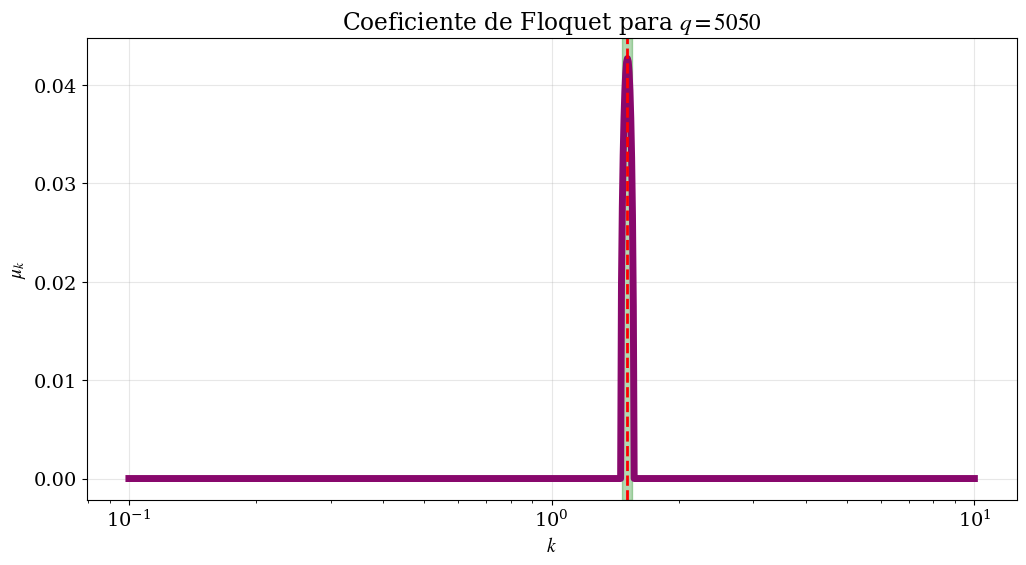

In [7]:
plt.figure(figsize=(12, 6))

plt.title(r'Coeficiente de Floquet para $q=5050$')
plt.plot(ks, np.real(mu), lw = 5, color = "#88086c")
plt.xlabel(r'$k$')
plt.ylabel(r'$\mu_k$')
plt.xscale('log')
plt.grid(alpha = 0.3)
plt.axvspan(k_delta[-1], k_delta[0], color='green', alpha=0.3)
plt.axvline(x=k_max, color='red', linestyle='--', lw=2)

# Scale factor $a(\tilde\eta)$

The file contains the following columns:

$\tilde\eta$ | $a$ | $a'$ | $\frac{a'}{a}$

In [8]:
expansion = False

if expansion == True:
    # load the file in aDat
    aDat = np.loadtxt(dir + "average_scale_factor.txt")
    
    #plot a
    plt.figure(0)
    plt.plot(aDat[:,0], aDat[:,1])
    plt.ylabel("$a$")
    plt.xlabel('$\\tilde\eta$')
    
    #plot a'
    plt.figure(1)
    plt.plot(aDat[:,0], aDat[:,2])
    plt.ylabel("$a'$")
    plt.xlabel('$\\tilde\eta$')
    
    
    #plot a'/a
    plt.figure(2)
    plt.plot(aDat[:,0], aDat[:,3])
    plt.ylabel("$a'/a$")
    plt.xlabel("$\\tilde\eta$");

else:
    aDat = None

# Volume average of fields

The files for the averages of the scalar fields contain the following columns:

$\eta$ | $\langle \tilde\phi_n \rangle$ | $\langle \tilde\phi'_n \rangle$ | $\langle \tilde\phi^2_n \rangle$ | $\langle \tilde\phi^{'2}_n \rangle$ | $\mathrm{rms}(\tilde\phi_n) $ | $\mathrm{rms}(\tilde\phi'_n) $

In [9]:
# Define a function for the plots, as we are gonna do 
# the same for both fields
def plot_fld(fldDat, fldNum="", aDat=None):
    plt.plot(fldDat[:,0], fldDat[:,1])
    plt.xlabel("$\\tilde\eta$")
    plt.ylabel("$\langle\phi_"+ fldNum +"\\rangle$")
    
    if aDat is not None:
        plt.figure(1)
        plt.plot(fldDat[:,0], aDat[:,1] * fldDat[:,1])
        plt.xlabel("$\\tilde\eta$")
        plt.ylabel("$a\cdot\langle\phi_"+ fldNum +" \\rangle$")
    
        plt.figure(2)
        plt.plot(fldDat[:,0], aDat[:,1] * fldDat[:,5])
        plt.xlabel("$\\tilde\eta$")
        plt.ylabel("$a\cdot\mathrm{rms}(\phi_"+ fldNum +")$")
        plt.yscale('log')

## Field $0$ (inflaton)

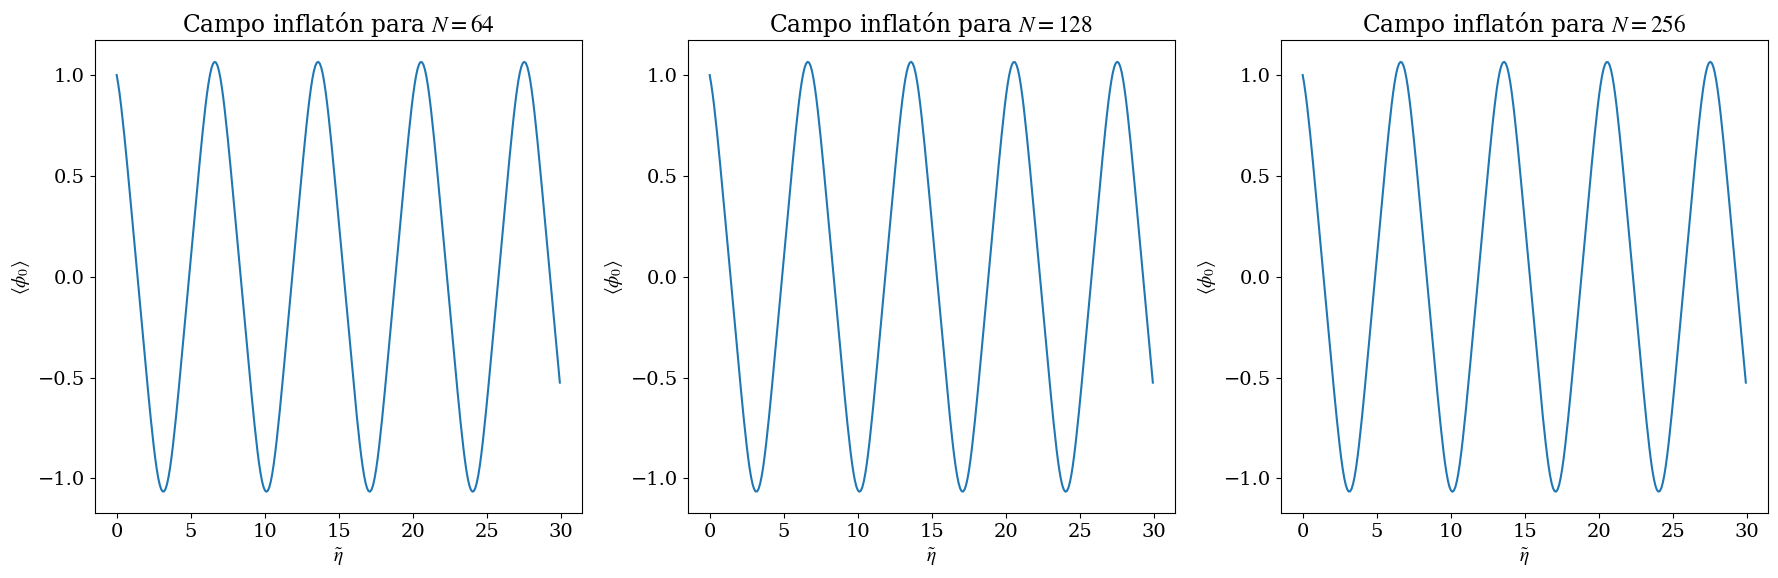

In [10]:
infDatN64 = np.loadtxt(dirN64 + "average_scalar_0.txt")
infDatN128 = np.loadtxt(dirN128 + "average_scalar_0.txt")
infDatN256 = np.loadtxt(dirN256 + "average_scalar_0.txt")

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plot_fld(infDatN64,"0",aDat)
plt.title(r'Campo inflatón para $N = 64$')

plt.subplot(1, 3, 2)
plot_fld(infDatN128,"0",aDat)
plt.title(r'Campo inflatón para $N = 128$')

plt.subplot(1, 3, 3)
plot_fld(infDatN256,"0",aDat)
plt.title(r'Campo inflatón para $N = 256$')

plt.tight_layout()
plt.show()

## Field $1$ (daughter field)

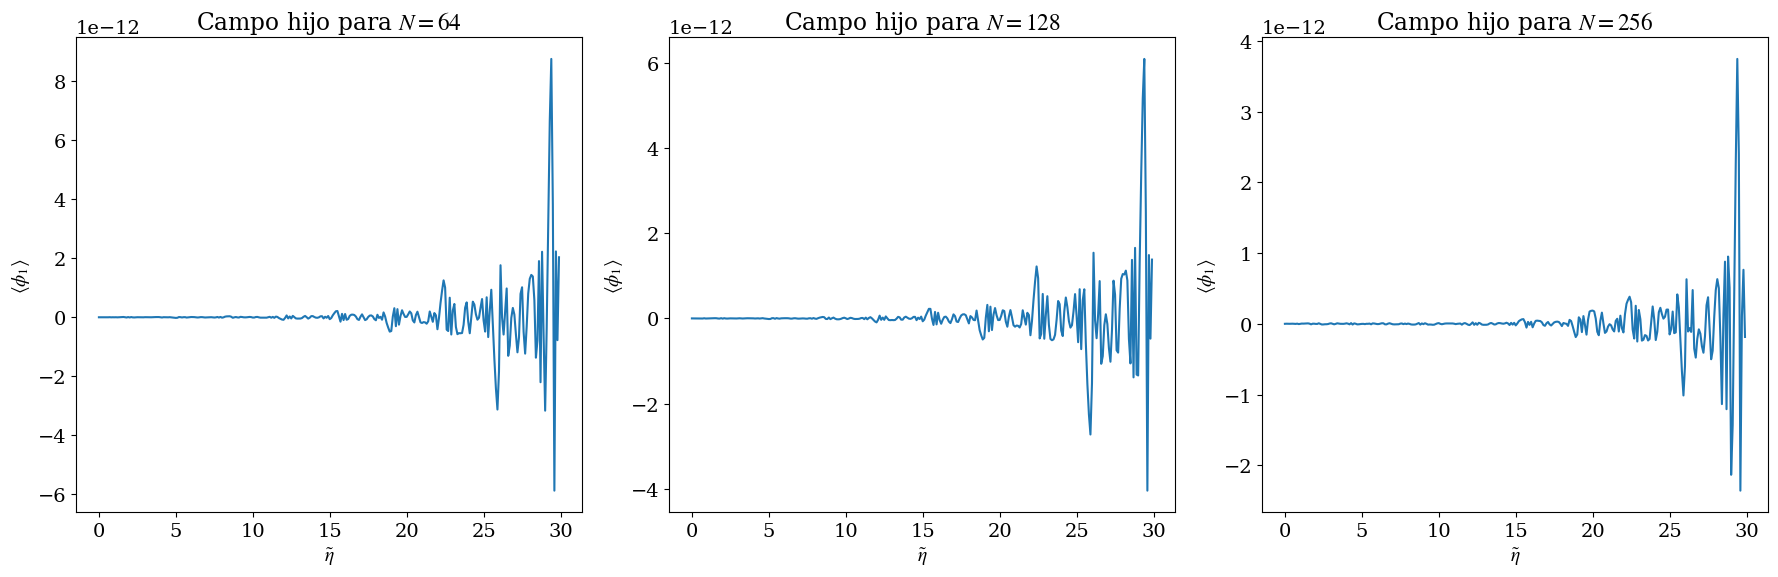

In [11]:
infDatN64 = np.loadtxt(dirN64 + "average_scalar_1.txt")
infDatN128 = np.loadtxt(dirN128 + "average_scalar_1.txt")
infDatN256 = np.loadtxt(dirN256 + "average_scalar_1.txt")

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plot_fld(infDatN64,"1",aDat)
plt.title(r'Campo hijo para $N = 64$')

plt.subplot(1, 3, 2)
plot_fld(infDatN128,"1",aDat)
plt.title(r'Campo hijo para $N = 128$')

plt.subplot(1, 3, 3)
plot_fld(infDatN256,"1",aDat)
plt.title(r'Campo hijo para $N = 256$')

plt.tight_layout()
plt.show()

# "Energy conservation" (the $1^{st}$ Friedmann's equation is satisfied)

The file  that checks the first Friedmann's equation contains

$\tilde\eta$ | $\frac{\langle LHS - RHS\rangle}{\langle LHS + RHS\rangle}$ | $\langle LHS \rangle$ | $\langle RHS \rangle$ 

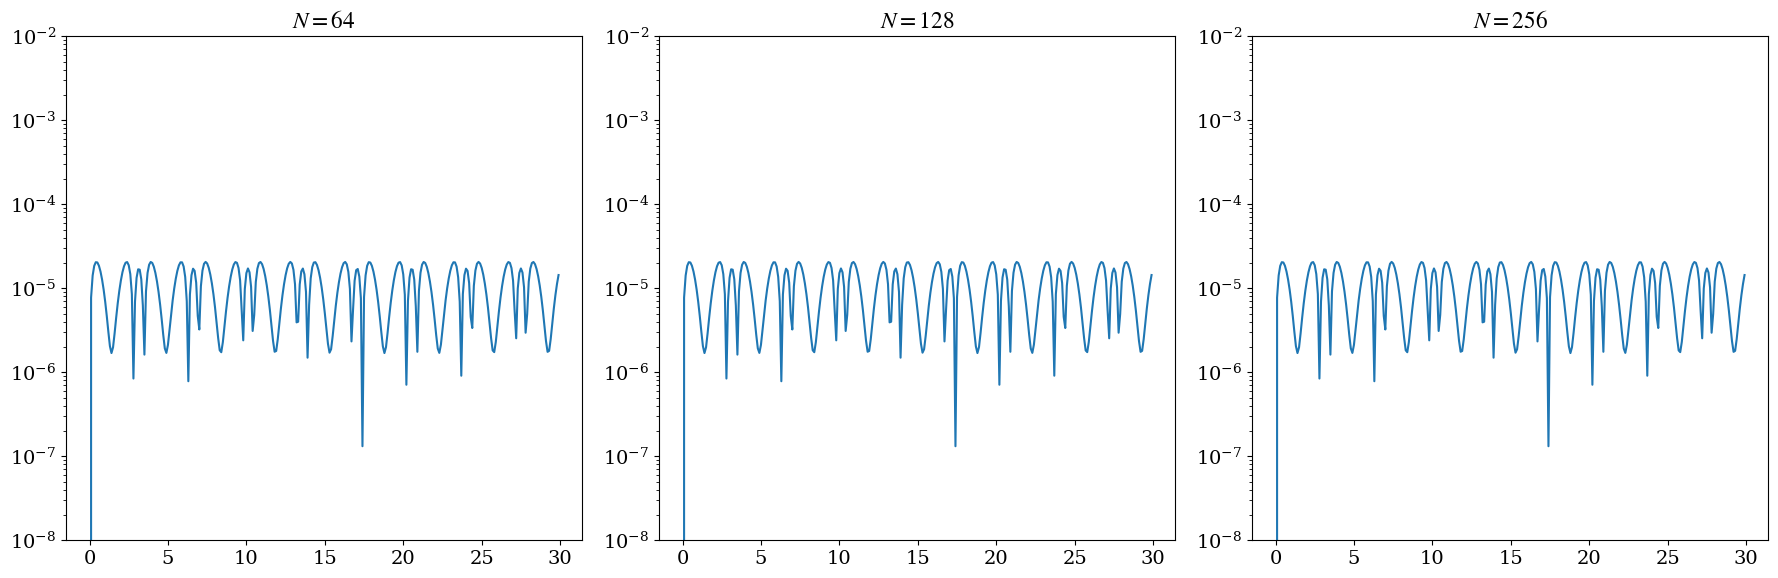

In [12]:
enConsDatN64 = np.loadtxt(dirN64 + "average_energy_conservation.txt")
enConsDatN128 = np.loadtxt(dirN128 + "average_energy_conservation.txt")
enConsDatN256 = np.loadtxt(dirN256 + "average_energy_conservation.txt")


plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.plot(enConsDatN64[:,0], enConsDatN64[:,1])
plt.yscale('log')
plt.ylim([1e-8,0.01])
plt.title(r'$N = 64$')

plt.subplot(1, 3, 2)
plt.plot(enConsDatN128[:,0], enConsDatN128[:,1])
plt.yscale('log')
plt.ylim([1e-8,0.01])
plt.title(r'$N = 128$')

plt.subplot(1, 3, 3)
plt.plot(enConsDatN256[:,0], enConsDatN256[:,1])
plt.yscale('log')
plt.ylim([1e-8,0.01])
plt.title(r'$N = 256$')

plt.tight_layout()
plt.show()

# Energy densities

The file with the energy densities contains

$\tilde\eta$ | $\tilde E_K^{(0)}$ | $\tilde E_G^{(0)}$ |$\dots$| $\tilde E_K^{(N_s-1)}$ | $\tilde E_G^{(N_s-1)}$ |  $\tilde E_V^{(0)}$ | $\dots$ |  $\tilde E_V^{(N_p-1)}$ | $\langle \tilde \rho \rangle$

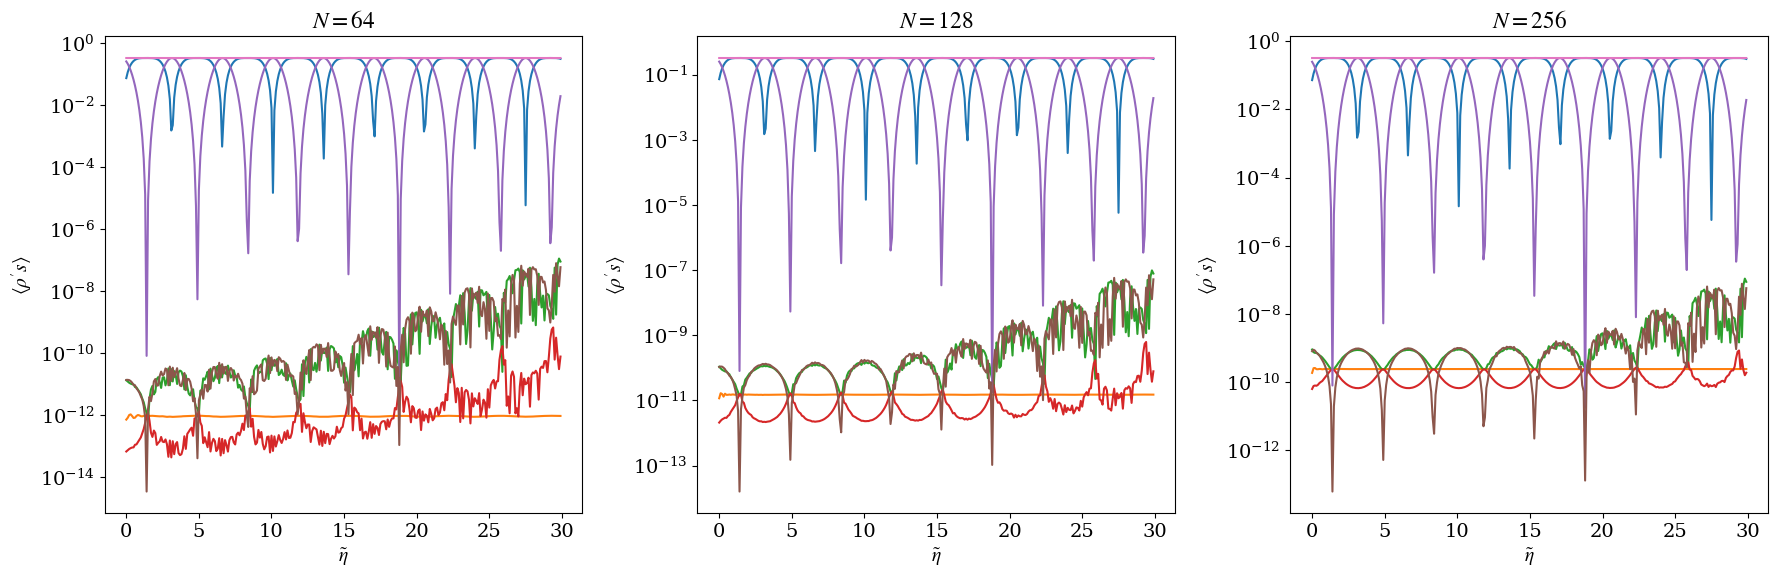

In [13]:
enDatN64 = np.loadtxt(dirN64 + "average_energies.txt")
enDatN128 = np.loadtxt(dirN128 + "average_energies.txt")
enDatN256 = np.loadtxt(dirN256 + "average_energies.txt")

nColumnsN64 = np.shape(enDatN64)[1]
nColumnsN128 = np.shape(enDatN128)[1]
nColumnsN256 = np.shape(enDatN256)[1]

# set explicitly different colors, so we know who is who
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown", "tab:pink"]

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
for i in range(1,nColumnsN64):
    plt.plot(enDatN64[:,0], enDatN64[:,i], color = colors[i-1])
plt.title(r'$N = 64$')
plt.yscale('log')
plt.xlabel("$\\tilde \eta$")
plt.ylabel("$\langle \\rho's\\rangle$")

plt.subplot(1, 3, 2)
for i in range(1,nColumnsN128):
    plt.plot(enDatN128[:,0], enDatN128[:,i], color = colors[i-1])
plt.title(r'$N = 128$')
plt.yscale('log')
plt.xlabel("$\\tilde \eta$")
plt.ylabel("$\langle \\rho's\\rangle$")

plt.subplot(1, 3, 3)
for i in range(1,nColumnsN256):
    plt.plot(enDatN256[:,0], enDatN256[:,i], color = colors[i-1])
plt.title(r'$N = 256$')
plt.yscale('log')
plt.xlabel("$\\tilde \eta$")
plt.ylabel("$\langle \\rho's\\rangle$")

plt.tight_layout()
plt.show()    

# Spectra

Spectra output varies depending on the option. The default one generates a txt file with the following columns:

$\tilde k$ | $\tilde\Delta_{\tilde\phi}$ | $\tilde\Delta_{\tilde\phi'}$ | $\tilde n_{\tilde\phi}$ | bin multiplicity

In [14]:
def load_spectrum(filename, comment = '#'):
    # The next few lines open the file and count
    # how many bins in one spectrum
    file = open(filename)
    nBins = 0
    # read first line
    line = file.readline()
    # while no blank we continue
    while line != "\n":
        # if not a comment line (header for instance)
        # we count one line
        if(line[0] != comment):
            nBins +=1
        # read next line
        line = file.readline()
    file.close()

    # now we know nBins. We still need to actually read the data.
    fileSp = np.loadtxt(filename, comments=comment)

    # find how many spectra are in the files
    nSpectra = len(fileSp) / nBins

    return fileSp, int(nBins), int(nSpectra)


def plot_spectrum(spectra, column, nBins, nSpectra, colormap='plasma'):
    colors = plt.get_cmap(colormap)
    norm = plt.Normalize(vmin=0, vmax=nSpectra-1)
    sm = plt.cm.ScalarMappable(cmap=colors, norm=norm)
    sm.set_array([])

    for i in range(nSpectra):
        plt.plot(
            spectra[i*nBins:(i+1)*nBins, 0],
            spectra[i*nBins:(i+1)*nBins, column],
            color=colors(i/nSpectra)
        )
    plt.xscale('log')
    plt.yscale('log')
    plt.grid(True, which="both", ls="--")
    plt.xlabel('$\\tilde k$', fontsize=20, labelpad=5)

    # Agrega la barra de colores asociada al eje actual
    cbar = plt.colorbar(sm, ax=plt.gca(), pad=0.02)
    cbar.set_label(r'$t$', fontsize=20, rotation=10)
    cbar.ax.tick_params(labelsize=16)

## Inflaton

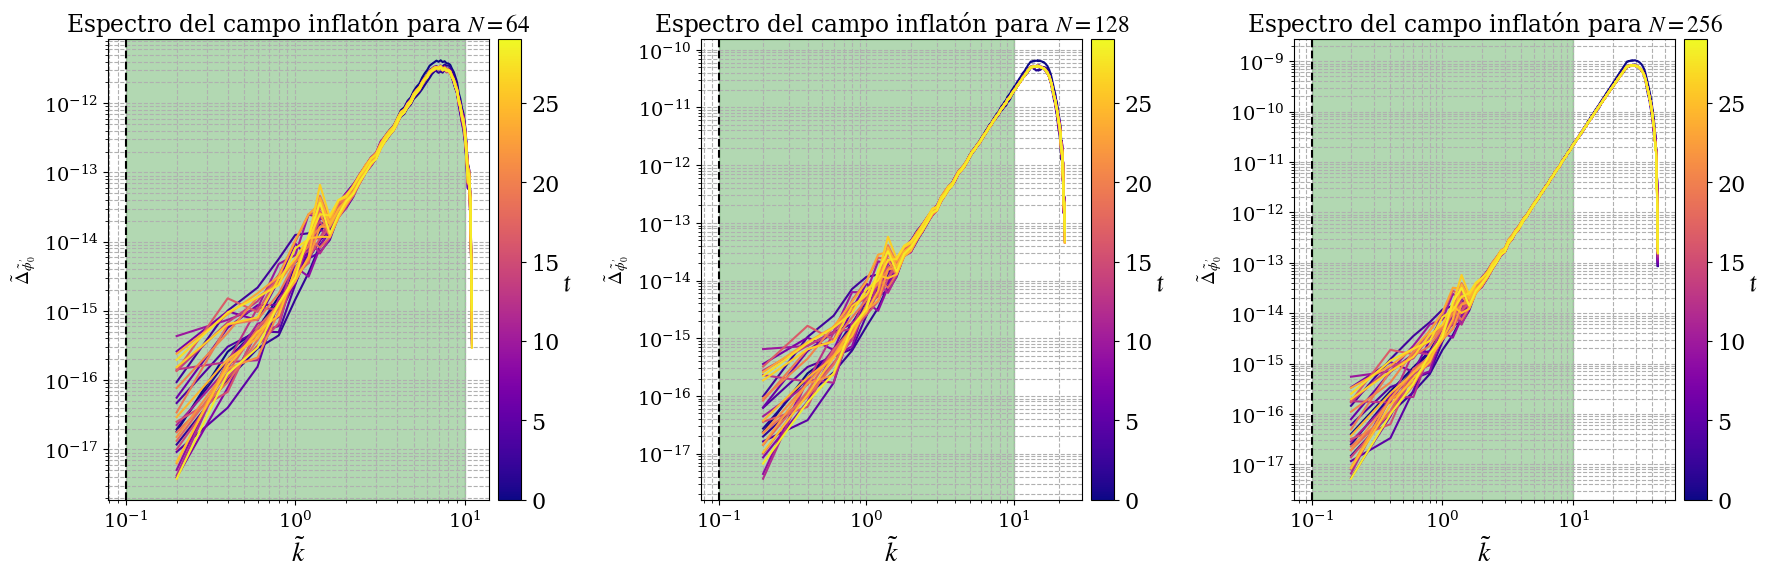

In [15]:
infSpN64, nBinsN64, nSpectraN64 = load_spectrum(dirN64 + "spectra_scalar_0.txt")
infSpN128, nBinsN128, nSpectraN128 = load_spectrum(dirN128 + "spectra_scalar_0.txt")
infSpN256, nBinsN256, nSpectraN256 = load_spectrum(dirN256 + "spectra_scalar_0.txt")

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plot_spectrum(infSpN64, 2,  nBinsN64, nSpectraN64)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_0\'}$')
plt.title(r'Espectro del campo inflatón para $N = 64$')
plt.axvline(k_maxq3, color='k', linestyle='--')
plt.axvspan(k_deltaq3[-1], k_deltaq3[0], color='green', alpha=0.3)

plt.subplot(1, 3, 2)
plot_spectrum(infSpN128, 2,  nBinsN128, nSpectraN128)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_0\'}$')
plt.title(r'Espectro del campo inflatón para $N = 128$')
plt.axvline(k_maxq3, color='k', linestyle='--')
plt.axvspan(k_deltaq3[-1], k_deltaq3[0], color='green', alpha=0.3)

plt.subplot(1, 3, 3)
plot_spectrum(infSpN256, 2,  nBinsN256, nSpectraN256)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_0\'}$')
plt.title(r'Espectro del campo inflatón para $N = 256$')
plt.axvline(k_maxq3, color='k', linestyle='--')
plt.axvspan(k_deltaq3[-1], k_deltaq3[0], color='green', alpha=0.3)

plt.tight_layout()
plt.show()

## Daughter field

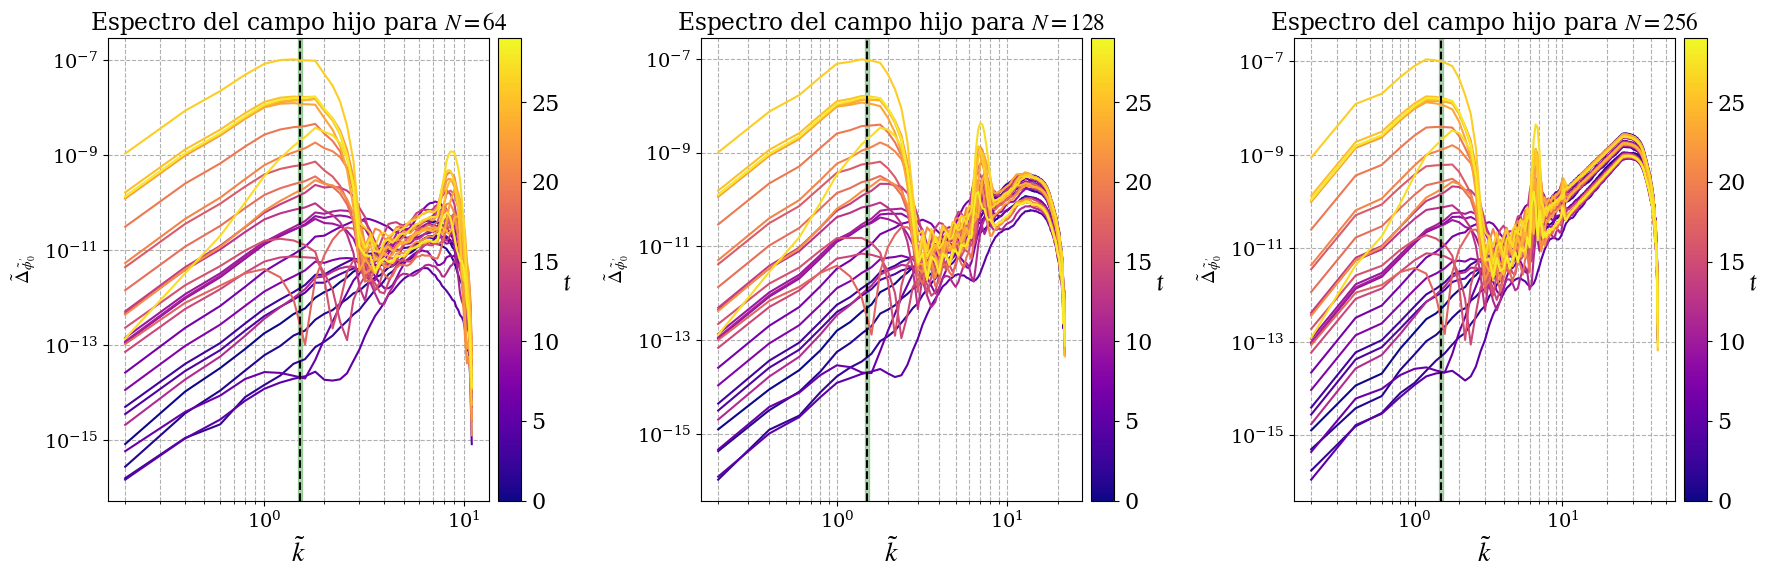

In [16]:
infSpN64, nBinsN64, nSpectraN64 = load_spectrum(dirN64 + "spectra_scalar_1.txt")
infSpN128, nBinsN128, nSpectraN128 = load_spectrum(dirN128 + "spectra_scalar_1.txt")
infSpN256, nBinsN256, nSpectraN256 = load_spectrum(dirN256 + "spectra_scalar_1.txt")

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plot_spectrum(infSpN64, 2,  nBinsN64, nSpectraN64)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_0\'}$')
plt.title(r'Espectro del campo hijo para $N = 64$')
plt.axvline(k_max, color='k', linestyle='--')
plt.axvspan(k_delta[-1], k_delta[0], color='green', alpha=0.3)

plt.subplot(1, 3, 2)
plot_spectrum(infSpN128, 2,  nBinsN128, nSpectraN128)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_0\'}$')
plt.title(r'Espectro del campo hijo para $N = 128$')
plt.axvline(k_max, color='k', linestyle='--')
plt.axvspan(k_delta[-1], k_delta[0], color='green', alpha=0.3)

plt.subplot(1, 3, 3)
plot_spectrum(infSpN256, 2,  nBinsN256, nSpectraN256)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_0\'}$')
plt.title(r'Espectro del campo hijo para $N = 256$')
plt.axvline(k_max, color='k', linestyle='--')
plt.axvspan(k_delta[-1], k_delta[0], color='green', alpha=0.3)

plt.tight_layout()
plt.show()

# GWs

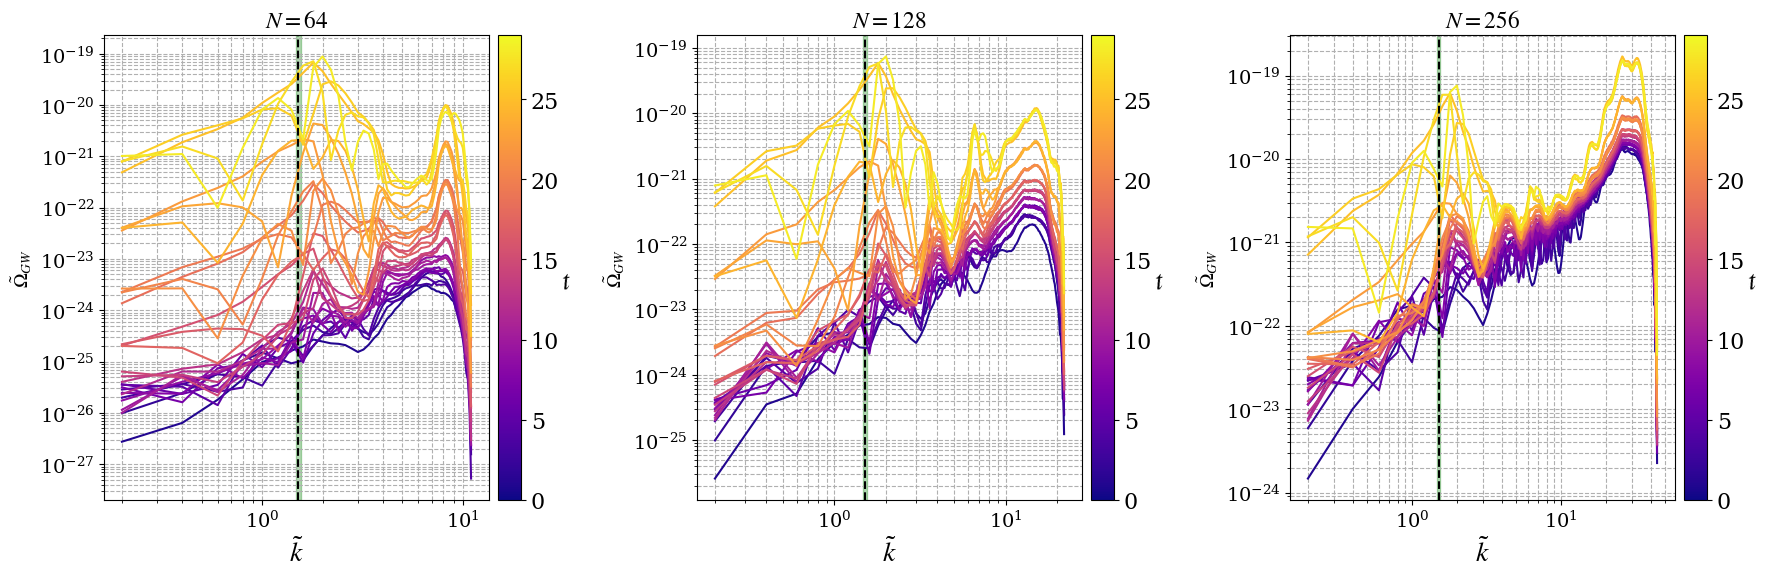

In [17]:
gwSpN64, nBinsN64, nSpectraN64 = load_spectrum(dirN64 + "spectra_gws.txt")
gwSpN128, nBinsN128, nSpectraN128 = load_spectrum(dirN128 + "spectra_gws.txt")
gwSpN256, nBinsN256, nSpectraN256 = load_spectrum(dirN256 + "spectra_gws.txt")

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plot_spectrum(gwSpN64, 1,  nBinsN64, nSpectraN64)
plt.ylabel('$\\tilde\Omega_{GW}$');
plt.title(r'$N = 64$')
plt.axvline(k_max, color='k', linestyle='--')
plt.axvspan(k_delta[-1], k_delta[0], color='green', alpha=0.3)

plt.subplot(1, 3, 2)
plot_spectrum(gwSpN128, 1,  nBinsN128, nSpectraN128)
plt.ylabel('$\\tilde\Omega_{GW}$');
plt.title(r'$N = 128$')
plt.axvline(k_max, color='k', linestyle='--')
plt.axvspan(k_delta[-1], k_delta[0], color='green', alpha=0.3)

plt.subplot(1, 3, 3)
plot_spectrum(gwSpN256, 1,  nBinsN256, nSpectraN256)
plt.ylabel('$\\tilde\Omega_{GW}$');
plt.title(r'$N = 256$')
plt.axvline(k_max, color='k', linestyle='--')
plt.axvspan(k_delta[-1], k_delta[0], color='green', alpha=0.3)

plt.tight_layout()
plt.show()